In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Ruta a tu carpeta de datos
dataset_path = "/media/aldrinchp/KAli-HDD/Subjects/NOVENO/Computer vision/Homeworks/homework1/DATASET"

# Clases disponibles
class_names = ["Celular", "Manzana"]

# Función para cargar imágenes de una carpeta
def load_images_from_folder(folder_path, class_name):
    images = []
    labels = []
    
    class_folder = os.path.join(folder_path, class_name)
    
    if not os.path.exists(class_folder):
        print(f"Carpeta no encontrada: {class_folder}")
        return images, labels
    
    for filename in os.listdir(class_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
            img_path = os.path.join(class_folder, filename)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir de BGR a RGB
                img = cv2.resize(img, (64, 64))  # Redimensionar a 64x64
                images.append(img)
                labels.append(class_names.index(class_name))
    
    return images, labels

# Cargar todas las imágenes
all_images = []
all_labels = []

for class_name in class_names:
    images, labels = load_images_from_folder(dataset_path, class_name)
    all_images.extend(images)
    all_labels.extend(labels)

# Convertir a numpy arrays
train_images = np.array(all_images)
train_labels = np.array(all_labels)

print(f"Total de imágenes cargadas: {len(train_images)}")
print(f"Forma de las imágenes: {train_images.shape}")
print(f"Clases: {class_names}")


Total de imágenes cargadas: 20
Forma de las imágenes: (20, 64, 64, 3)
Clases: ['Celular', 'Manzana']


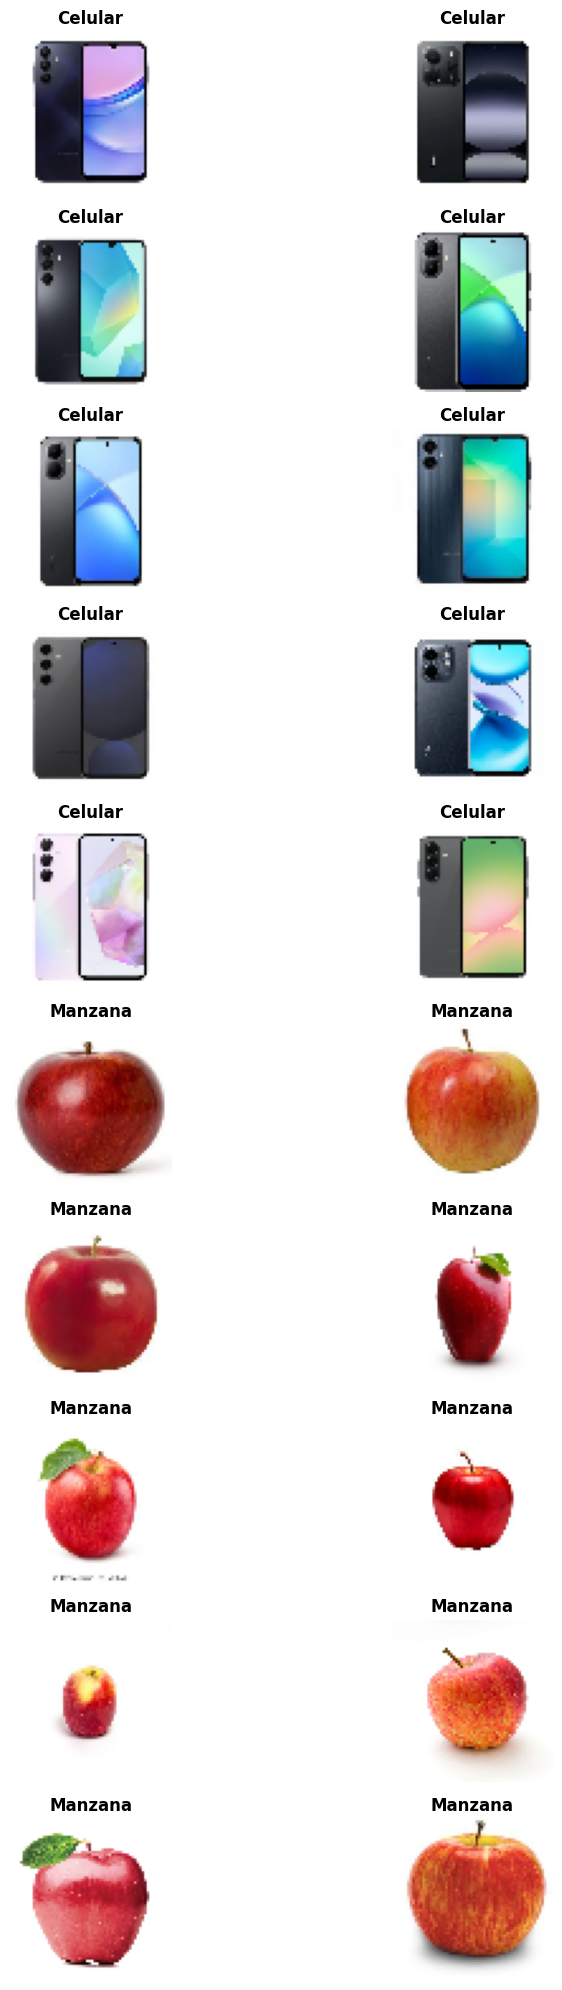

Se muestran 20 imágenes: 10 de Celular y 10 de Manzana.


In [2]:
# Seleccionar 10 imágenes de cada clase
celular_indices = np.where(train_labels == 0)[0]  # Índices de Celular (clase 0)
manzana_indices = np.where(train_labels == 1)[0]  # Índices de Manzana (clase 1)

# Seleccionar aleatorios de cada clase
selected_celular = np.random.choice(celular_indices, min(10, len(celular_indices)), replace=False)
selected_manzana = np.random.choice(manzana_indices, min(10, len(manzana_indices)), replace=False)

# Combinar los índices seleccionados
selected_display_indices = np.concatenate([selected_celular, selected_manzana])

# Crear figura y subplots para 20 imágenes (10x2)
fig, axes = plt.subplots(10, 2, figsize=(10, 20))
axes = axes.flatten()  # Aplanar el array de axes para iteración más fácil

# Iterar a través de los índices seleccionados y graficar cada imagen
for i, idx in enumerate(selected_display_indices):
    image = train_images[idx]
    label = train_labels[idx]
    class_name = class_names[label]
    
    axes[i].imshow(image)
    axes[i].set_title(class_name, fontsize=12, fontweight='bold')
    axes[i].axis('off')  # Apagar marcas de ejes y etiquetas

# Ajustar layout para evitar superposición de títulos
plt.tight_layout()

# Mostrar el gráfico
plt.show()
print(f"Se muestran 20 imágenes: 10 de Celular y 10 de Manzana.")

In [3]:
edge_detection_kernel = np.array([[[-1, 0, 1],
                                  [-1, 0, 1],
                                  [-1, 0, 1]]],  dtype=np.float32)  

sharpening_kernel = np.array([[[ 0, -1,  0],
                              [-1,  5, -1],
                              [ 0, -1,  0]]], dtype=np.float32)

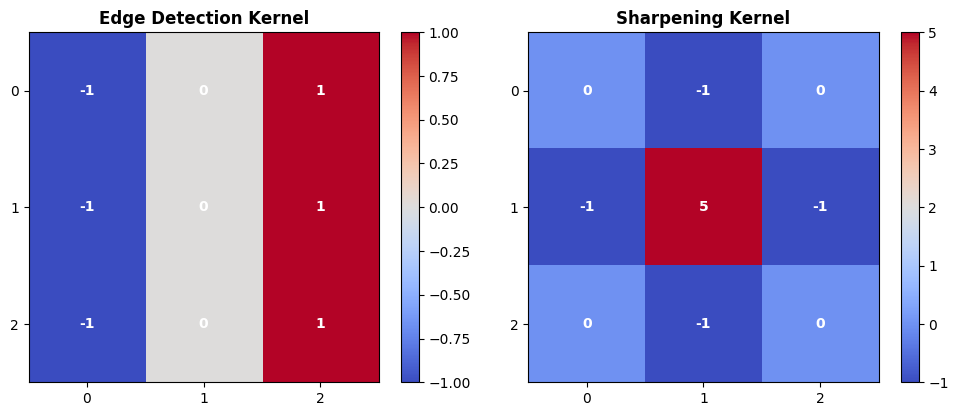

Kernels visualizados:


In [4]:
# Visualizar los kernels
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Remover la dimensión extra de los kernels para visualización
edge_kernel_2d = edge_detection_kernel[0]
sharpen_kernel_2d = sharpening_kernel[0]

# Plotear edge detection kernel
im1 = axes[0].imshow(edge_kernel_2d, cmap='coolwarm')
axes[0].set_title('Edge Detection Kernel', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(3))
axes[0].set_yticks(range(3))
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f'{edge_kernel_2d[i, j]:.0f}', ha='center', va='center', color='white', fontweight='bold')
plt.colorbar(im1, ax=axes[0])

# Plotear sharpening kernel
im2 = axes[1].imshow(sharpen_kernel_2d, cmap='coolwarm')
axes[1].set_title('Sharpening Kernel', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(3))
axes[1].set_yticks(range(3))
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{sharpen_kernel_2d[i, j]:.0f}', ha='center', va='center', color='white', fontweight='bold')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print("Kernels visualizados:")

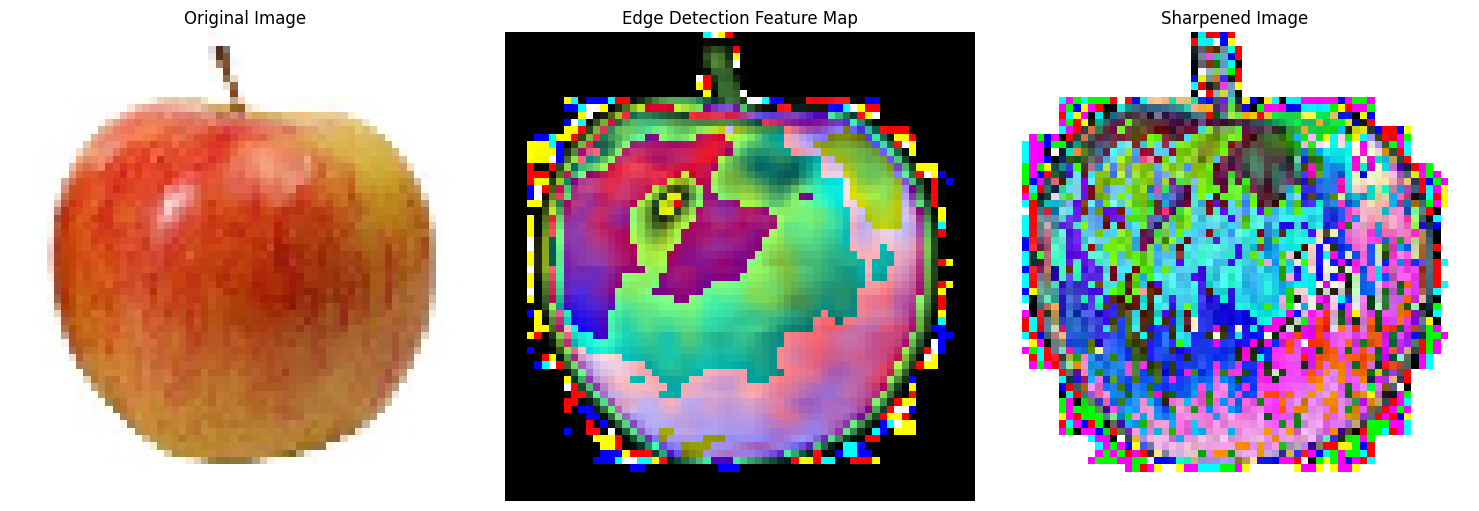

Original image, edge detection feature map, and sharpened image are displayed.


In [16]:
from scipy.ndimage import convolve
import matplotlib.pyplot as plt

# Select a sample image
sample_image = train_images[13]

# Apply edge detection kernel
edge_feature_map = convolve(sample_image, edge_detection_kernel)

# Apply sharpening kernel
sharpened_image = convolve(sample_image, sharpening_kernel)

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Display original image
axes[0].imshow(sample_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Display edge detection feature map
axes[1].imshow(edge_feature_map, cmap='gray')
axes[1].set_title('Edge Detection Feature Map')
axes[1].axis('off')

# Display sharpened image
axes[2].imshow(sharpened_image, cmap='gray')
axes[2].set_title('Sharpened Image')
axes[2].axis('off')

# Adjust layout and display plot
plt.tight_layout()
plt.show()

print("Original image, edge detection feature map, and sharpened image are displayed.")

In [6]:
import numpy as np
from scipy.ndimage import convolve

def extract_features(image, edge_kernel, sharpen_kernel):
    """
    Extracts features from an image by applying edge detection and sharpening kernels,
    and computing the mean pixel intensity of the original and filtered images.
    """
    # Apply edge detection kernel
    edge_feature_map = convolve(image, edge_kernel)

    # Apply sharpening kernel
    sharpened_image = convolve(image, sharpen_kernel)

    # Compute feature vector (mean of original, edge map, and sharpened image)
    features = [
        np.mean(image),
        np.mean(edge_feature_map),
        np.mean(sharpened_image)
    ]
    return np.array(features)

print("Feature extraction function defined.")

Feature extraction function defined.


In [7]:
train_features = []
train_labels_features = []

for i, image in enumerate(train_images):
    features = extract_features(image, edge_detection_kernel, sharpening_kernel)
    train_features.append(features)
    train_labels_features.append(train_labels[i])

train_features = np.array(train_features)
train_labels_features = np.array(train_labels_features)

print(f"Extracted features for {len(train_features)} training images.")
print(f"Shape of training features: {train_features.shape}")
print(f"Shape of training labels: {train_labels_features.shape}")

Extracted features for 20 training images.
Shape of training features: (20, 3)
Shape of training labels: (20,)


In [8]:
np.unique(train_labels_features)

array([0, 1])

In [9]:
class_centroids = {}

# Assuming filtered_train_labels has been mapped to 0 for Celular and 1 for Manzana
# and train_labels_features contains these numerical labels.

for class_label in np.unique(train_labels_features):
    # Get features for the current class
    class_features = train_features[train_labels_features == class_label]

    # Calculate the centroid (mean of features) for the current class
    centroid = np.mean(class_features, axis=0)
    class_centroids[class_label] = centroid

# Display the calculated centroids
print("Calculated Class Centroids:")
for label, centroid in class_centroids.items():
    print(f"Class {class_names[label]} (Label {label}): {centroid}")

Calculated Class Centroids:
Class Celular (Label 0): [171.3559082  114.50592448 154.6184082 ]
Class Manzana (Label 1): [195.83341471  58.70385742 183.77716471]


In [10]:
def classify_image(features, class_centroids):
    """
    Classifies an image based on its feature vector and pre-calculated class centroids
    using Euclidean distance.
    """
    distances = {}
    for class_label, centroid in class_centroids.items():
        # Calculate Euclidean distance
        dist = np.linalg.norm(features - centroid)
        distances[class_label] = dist

    # Predict the class with the minimum distance
    predicted_class = min(distances, key=distances.get)
    return predicted_class

print("Classification function defined.")

Classification function defined.


In [11]:
test_features = []

for image in train_images:
    features = extract_features(image, edge_detection_kernel, sharpening_kernel)
    test_features.append(features)

test_features = np.array(test_features)

print(f"Extracted features for {len(test_features)} test images.")
print(f"Shape of test features: {test_features.shape}")

Extracted features for 20 test images.
Shape of test features: (20, 3)


In [12]:
test_predictions = []

for features in test_features:
    predicted_class = classify_image(features, class_centroids)
    test_predictions.append(predicted_class)

test_predictions = np.array(test_predictions)

print(f"Generated predictions for {len(test_predictions)} test images.")
print(f"Shape of test predictions: {test_predictions.shape}")

Generated predictions for 20 test images.
Shape of test predictions: (20,)


In [13]:
correct_predictions = np.sum(test_predictions == train_labels)
total_test_images = len(train_labels)

accuracy = correct_predictions / total_test_images

print(f"Number of correct predictions: {correct_predictions}")
print(f"Total test images: {total_test_images}")
print(f"Classifier Accuracy: {accuracy * 100:.2f}%")

if accuracy * 100 >= 70:
    print("Target accuracy of 70% achieved!")
else:
    print("Target accuracy of 70% not achieved. Further improvements might be needed.")

Number of correct predictions: 17
Total test images: 20
Classifier Accuracy: 85.00%
Target accuracy of 70% achieved!


In [14]:
print(test_predictions)
print(train_labels)

[0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 1 0 1 1 1]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
